In [10]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver


In [11]:
class state(TypedDict):
    topic:str
    joke:str
    explanation:str

In [12]:
chatmodel = ChatOllama(model = "llama3.2:1b", temperature=0.7)

In [17]:
def joke_generation(state):
    topic = state['topic']
    prompt = f"generate a joke based on the given topic: {topic}"
    res = chatmodel.invoke(prompt).content
    return {"joke":res}
def joke_explanation(state):
    topic = state['topic']
    joke = state['joke']
    prompt = f"Give some explanation of the joke, joke: {joke}, which prepare based on the given topic: {topic}"
    explan = chatmodel.invoke(prompt).content
    return {"explanation":explan}

In [18]:
checkpointer = InMemorySaver()
graph = StateGraph(state)

graph.add_node("joke_generation",joke_generation)
graph.add_node("joke_explanation",joke_explanation)

graph.add_edge(START,"joke_generation")
graph.add_edge("joke_generation","joke_explanation")
graph.add_edge("joke_explanation",END)
workflow = graph.compile(checkpointer=checkpointer)

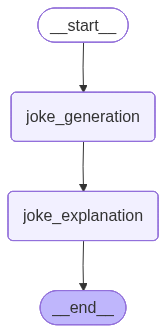

In [19]:
workflow

In [22]:
initial_state = {"topic":"pizza"}
config = {"configurable":{"thread_id":"1"}}
workflow.invoke(initial_state,config=config)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.',
 'explanation': 'This joke plays on the double meaning of "crusty" in the context of a pizza. On one hand, "crusty" refers to the outer layer of a pizza dough, which is typically crispy and crunchy.\n\nOn the other hand, "crusty under the pressure" is an idiomatic expression that means feeling strained or overwhelmed by external pressures, such as work or life stress.\n\nSo, the joke is funny because it takes these two meanings of "crusty" and combines them in a clever way to create a pun on the phrase. It\'s like the pizza is saying, "I\'m feeling stressed out about all the toppings I have to deal with, but also feeling overwhelmed by the pressure of being a popular food item!"'}

In [23]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.', 'explanation': 'This joke plays on the double meaning of "crusty" in the context of a pizza. On one hand, "crusty" refers to the outer layer of a pizza dough, which is typically crispy and crunchy.\n\nOn the other hand, "crusty under the pressure" is an idiomatic expression that means feeling strained or overwhelmed by external pressures, such as work or life stress.\n\nSo, the joke is funny because it takes these two meanings of "crusty" and combines them in a clever way to create a pun on the phrase. It\'s like the pizza is saying, "I\'m feeling stressed out about all the toppings I have to deal with, but also feeling overwhelmed by the pressure of being a popular food item!"'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc52-2c13-6016-800a-e085ac555182'}}, metadata={'source': 'loop', 'step': 10, '

In [25]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty under the pressure.', 'explanation': 'This joke plays on the double meaning of "crusty" in the context of a pizza. On one hand, "crusty" refers to the outer layer of a pizza dough, which is typically crispy and crunchy.\n\nOn the other hand, "crusty under the pressure" is an idiomatic expression that means feeling strained or overwhelmed by external pressures, such as work or life stress.\n\nSo, the joke is funny because it takes these two meanings of "crusty" and combines them in a clever way to create a pun on the phrase. It\'s like the pizza is saying, "I\'m feeling stressed out about all the toppings I have to deal with, but also feeling overwhelmed by the pressure of being a popular food item!"'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc52-2c13-6016-800a-e085ac555182'}}, metadata={'source': 'loop', 'step': 10, 

In [28]:
# lets change the thread id:
initial_state = {"topic":"apple"}
config2 = {"configurable":{"thread_id":"2"}}
workflow.invoke(initial_state,config=config2)

{'topic': 'apple',
 'joke': 'Why did the apple join the gym?\n\nBecause it wanted to get some core strength.',
 'explanation': 'This joke is a play on words. The phrase "core strength" has a double meaning here. In fitness and exercise, "core strength" refers to the muscles that support your body\'s center, such as your abs. However, in a literal sense, an apple is also known for having a core or central part.\n\nThe joke relies on this wordplay by using "core strength" to reference both the physical aspect of getting stronger and the fact that an apple has a central part. It\'s a lighthearted and humorous way to poke fun at the idea that apples are typically thought of as being soft or delicate, but in a clever and unexpected twist.'}

In [29]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'apple', 'joke': 'Why did the apple join the gym?\n\nBecause it wanted to get some core strength.', 'explanation': 'This joke is a play on words. The phrase "core strength" has a double meaning here. In fitness and exercise, "core strength" refers to the muscles that support your body\'s center, such as your abs. However, in a literal sense, an apple is also known for having a core or central part.\n\nThe joke relies on this wordplay by using "core strength" to reference both the physical aspect of getting stronger and the fact that an apple has a central part. It\'s a lighthearted and humorous way to poke fun at the idea that apples are typically thought of as being soft or delicate, but in a clever and unexpected twist.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc65-881b-6be9-800a-7b25b06edd79'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-03-31T05:56:22.523974+00:00',

In [31]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'apple', 'joke': 'Why did the apple join the gym?\n\nBecause it wanted to get some core strength.', 'explanation': 'This joke is a play on words. The phrase "core strength" has a double meaning here. In fitness and exercise, "core strength" refers to the muscles that support your body\'s center, such as your abs. However, in a literal sense, an apple is also known for having a core or central part.\n\nThe joke relies on this wordplay by using "core strength" to reference both the physical aspect of getting stronger and the fact that an apple has a central part. It\'s a lighthearted and humorous way to poke fun at the idea that apples are typically thought of as being soft or delicate, but in a clever and unexpected twist.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc65-881b-6be9-800a-7b25b06edd79'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-03-31T05:56:22.523974+00:00'

### time travel

In [32]:
workflow.invoke(None,{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc61-1505-6493-8000-16fdfa8fa94e'}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions.',
 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "tangled" - both as a physical description of pasta being twisted and turned, and as an emotional state where someone is feeling overwhelmed or confused.\n\nThe punchline is a common idiom that means to be feeling a mix of emotions, like being in two places at once (in this case, on the plate and inside one\'s head). The joke is funny because it takes a familiar concept (spaghetti going to therapy) and gives it a literal, pasta-related twist.\n\nIt\'s also worth noting that the joke is self-aware and acknowledges the wordplay, which adds to its humor. It\'s a lighthearted and clever joke that pokes fun at the idea of pasta being something you\'d want to talk about in therapy.'}

In [34]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions.', 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "tangled" - both as a physical description of pasta being twisted and turned, and as an emotional state where someone is feeling overwhelmed or confused.\n\nThe punchline is a common idiom that means to be feeling a mix of emotions, like being in two places at once (in this case, on the plate and inside one\'s head). The joke is funny because it takes a familiar concept (spaghetti going to therapy) and gives it a literal, pasta-related twist.\n\nIt\'s also worth noting that the joke is self-aware and acknowledges the wordplay, which adds to its humor. It\'s a lighthearted and clever joke that pokes fun at the idea of pasta being something you\'d want to talk about in therapy.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkp

In [36]:
# we can update also intermediate state value in langgraph execution
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc61-1505-6493-8000-16fdfa8fa94e'}},{'topic':'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f12cc8a-c516-65a6-8001-9a8930ae47e7'}}

In [37]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('joke_generation',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc8a-c516-65a6-8001-9a8930ae47e7'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-31T06:13:02.129279+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc61-1505-6493-8000-16fdfa8fa94e'}}, tasks=(PregelTask(id='666890e5-e806-47ba-ad1f-a8586c1acf31', name='joke_generation', path=('__pregel_pull', 'joke_generation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'somosa'}, next=('joke_generation',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc88-bc27-6a86-8001-0930e92bb5b3'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-31T06:12:07.505562+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'check

In [38]:
workflow.invoke(None,{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12cc8a-c516-65a6-8001-9a8930ae47e7'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling wrapped up in its emotions.',
 'explanation': 'That\'s a clever play on words. The joke is setting up the expectation that the punchline will be related to the food item (samosa) and its characteristics, but instead, it subverts this expectation by using the phrase "wrapped up in its emotions," which has a double meaning.\n\nIn the context of the samosa, "wrapped" can refer to both the pastry wrapping around the filling and the emotional turmoil that people often experience. The joke is making a pun on these two meanings, creating a humorous connection between the food item and the concept of emotional complexity.'}